# In-situ sanity checks — GEM GeoBasis Disko AWS2 (Qeqertarsuaq)

**Goal:** qualify the GEM (Greenland Ecosystem Monitoring) AWS2 station as an in-situ **snow**
reference for validating snowfall rate against climate-model and earth-observation data, for the
same two EO periods used in `dmi_sanity_checks.ipynb`:

| Period | Range |
|---|---|
| **A** | 2023-04-08 → 2023-07-10 |
| **B** | all of 2025 |

**The site.** AWS2 stands in Østerlien, ~100 m east of Arctic Station, Qeqertarsuaq
(69.25349 N, −53.51413 E, ~25 m a.s.l.) — **~250 m from DMI station 421900**, whose
temperature/humidity sensors failed our DMI sanity checks in both periods. GEM AWS2 is therefore
the replacement in-situ record for Qeqertarsuaq *and* the only local snow-depth measurement
(DMI has no snow depth anywhere in Greenland). Logging interval: **30 minutes**.

**Source files** (`GEM/`, tab-separated, `-9999` = missing, timestamps in **UTC−3** — converted
to UTC here so everything aligns with the DMI/EO data):

| Dataset | DOI | Used columns |
|---|---|---|
| AWS2-Meteorology | 10.17897/CSZT-F010 | air T, RH, pressure, wind avg/max/dir, SW in/out, albedo, surface T (from LW out) |
| AWS2-SnowDepth | 10.17897/SCXW-S288 | snow depth (sonic SR50a, point below mast) |
| AWS2-SnowAirTemperature | 10.17897/P479-1G98 | 10-cm thermistor only (snow-presence cross-check) |

**Variable selection rationale** (Meteorology carries 21 columns; only the snowfall-relevant ones
are kept): snow depth is the snowfall signal (Δdepth ⇒ accumulation events); air T partitions
rain/snow; wind flags drifting-snow artefacts in Δdepth; SW out/in (albedo) is an independent
fresh-snow indicator; surface temperature (derived from longwave-out) indicates melt; RH and
pressure support coherence checks with DMI/EO. Dropped: PAR (3 sensors, vegetation-oriented),
battery voltage, radiometer housekeeping temperatures, and the redundant net-radiation columns.
Of the 15 thermistor levels only the 10-cm one is used: per the metadata these sensors are **only
valid when snow-covered** — the 10-cm level, compared against air temperature and snow depth,
tells us when snow actually covered the ground.

**Documented instrument history** (from the GEM descriptions, must be visible in the checks):
a service gap 2022-09-10 → 15; a **data-communication failure 2023-04-23 → 2023-05-13** — inside
period A; the T/RH and wind sensors were replaced on 2022-09-10; albedo is only computed 11:00–15:00
and deleted 15 Nov–1 Feb (low sun/polar night); the sonic snow sensor shows small fluctuations even
with no snow on the ground (small negative depths near bare ground).

**Outputs** (`results/`): `gem_aws2_verdicts.csv` and `clean_GEM_AWS2_<period>.csv` (UTC index,
critical flags masked, small negative snow depths clamped to 0).

## 1. Setup & configuration

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

BASE = Path.cwd()
GEM_DIR = BASE / 'GEM'
RESULTS_DIR = BASE / 'results'; RESULTS_DIR.mkdir(exist_ok=True)
assert GEM_DIR.exists(), 'Run this notebook from the project root (the folder containing GEM/).'

SITE = dict(name='GEM GeoBasis Disko AWS2', lat=69.25349, lon=-53.51413, elev_m=25,
            tz_offset_h=3)   # timestamps are UTC-3; +3 h converts to UTC

PERIODS = {
    'A': ('2023-04-08 00:00', '2023-07-10 23:59'),
    'B': ('2025-01-01 00:00', '2025-12-31 23:59'),
}
STEPS_PER_DAY = 48   # 30-minute logging

FILES = {
    'met':  GEM_DIR / 'AWS2-Meteorology' / 'AWS2-Meteorology_10.17897_CSZT-F010_data.txt',
    'snow': GEM_DIR / 'AWS2-SnowDepth' / 'AWS2-SnowDepth_10.17897_SCXW-S288_data.txt',
    'stemp': GEM_DIR / 'AWS2-SnowAirTemperature' / 'AWS2-SnowAirTemperature_10.17897_P479-1G98_data.txt',
}

# source column -> our variable key (only the snowfall-relevant subset)
COLUMNS = {
    'met': {
        'Air temperature_°C':                 'T_air',
        'Relative humidity_%':                'RH',
        'Air pressure_hPa':                   'P_air',
        'Wind speed_avg_ms-1':                'wind_avg',
        'Wind speed_max_ms-1':                'wind_max',
        'Wind direction_degrees':             'wind_dir',
        'Shortwave incoming radiation_Wm-2':  'SW_in',
        'Shortwave outgoing radiation_Wm-2':  'SW_out',
        'Albedo':                             'albedo',
        'Ground temperature_°C':              'T_surface',
    },
    'snow': {'Snow depth_m': 'snow_depth'},
    'stemp': {'Snow/Air temperature_10cm_P1_°C': 'T_snow10cm'},
}

# per-variable metadata: display name, unit, physical bounds, spike limit (per hour), core?
VARS = {
    'T_air':      dict(short='Air temp',       unit='degC', lo=-45, hi=25,   spike=10,   core=True),
    'RH':         dict(short='Humidity',       unit='%',    lo=5,   hi=104,  spike=60,   core=True),
    'P_air':      dict(short='Pressure',       unit='hPa',  lo=930, hi=1060, spike=10,   core=True),
    'wind_avg':   dict(short='Wind avg',       unit='m/s',  lo=0,   hi=50,   spike=None, core=True),
    'wind_max':   dict(short='Wind max',       unit='m/s',  lo=0,   hi=60,   spike=None, core=False),
    'wind_dir':   dict(short='Wind dir',       unit='deg',  lo=0,   hi=360,  spike=None, core=False),
    'SW_in':      dict(short='SW in',          unit='W/m2', lo=0,   hi=1200, spike=None, core=False),
    'SW_out':     dict(short='SW out',         unit='W/m2', lo=0,   hi=1000, spike=None, core=False),
    'albedo':     dict(short='Albedo',         unit='-',    lo=0,   hi=1,    spike=None, core=False),
    'T_surface':  dict(short='Surface temp',   unit='degC', lo=-55, hi=45,   spike=None, core=False),
    'snow_depth': dict(short='Snow depth',     unit='m',    lo=-0.02, hi=2,  spike=None, core=True),
    'T_snow10cm': dict(short='Snow T 10cm',    unit='degC', lo=-45, hi=45,   spike=None, core=False),
}
CORE_VARS = [v for v, m in VARS.items() if m['core']]

THRESHOLDS = dict(
    completeness_pass=0.80,   # every core var must reach this (after masking) for PASS
    completeness_min=0.50,    # any core var below this -> FAIL
    flagged_pass=0.005,       # critical-flag fraction per core var allowed for PASS
    flagged_max=0.02,         # any core var above this -> FAIL
    persistence_frac=0.05,    # stuck-sensor flags above this fraction downgrade PASS -> WARNINGS
    gap_report_hours=6,       # missing-value runs longer than this are listed
    persistence_hours=24,     # a constant value for at least this long = stuck sensor
    snow_step_max=0.10,       # |depth change| per 30-min step above this = sonic noise (critical)
    snow_neg_clamp=-0.02,     # depths in [snow_neg_clamp, 0) are bare-ground noise -> clamped to 0
    melt_T=3.0,               # daily mean T above this ...
    melt_rise=0.03,           # ... with daily depth rise above this (m) -> inconsistency (warning)
    swout_tol=10.0,           # SW out may exceed SW in by at most this (W/m2)
    cross_dt=8.0,             # |T diff| vs DMI Aasiaat beyond this -> warning (70 km across the bay)
    cross_dp=5.0,             # |offset-corrected P diff| vs DMI Aasiaat beyond this -> warning
)

CRITICAL_CHECKS = {'range', 'spike', 'internal', 'snow_negative', 'snow_step'}   # masked in export
WARNING_CHECKS = {'persistence', 'melt_inconsistency', 'cross_product'}          # reported only

# --- chart style: light mode, from the validated reference palette (dataviz skill) ---
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
SURFACE, GRID, BASELINE, NEUTRAL = '#fcfcfb', '#e1e0d9', '#c3c2b7', '#f0efec'
SERIES = '#2a78d6'                        # categorical slot 1 (blue) - the only series hue used
CRITICAL_C, WARNING_C = '#d03b3b', '#fab219'   # status colors: flags only, never a series
SEQ_RAMP = ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']
CMAP_SEQ = LinearSegmentedColormap.from_list('seq_blue', SEQ_RAMP)
mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': BASELINE, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.axisbelow': True,
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'Arial', 'DejaVu Sans'],
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'figure.dpi': 110,
    'legend.frameon': False,
})


## 2. Load & merge the three AWS2 files

The three files share one 30-minute grid. Each is read tab-separated (`-9999` → NaN), reduced to
the selected columns, merged on the timestamp, and shifted **+3 h from UTC−3 to UTC**. The full
merged record is kept in `full`; the periods are sliced from it.

In [2]:
def load_gem(path, colmap):
    df = pd.read_csv(path, sep='\t', encoding='utf-8-sig', na_values=['-9999', -9999, '-9999.0'])
    time_col = df.columns[1]   # 'Time' or 'Time (UTC-3)'
    ts = pd.to_datetime(df['Date'] + ' ' + df[time_col]) + pd.Timedelta(hours=SITE['tz_offset_h'])
    out = df[[c for c in colmap if c in df.columns]].rename(columns=colmap)
    missing = [c for c in colmap if c not in df.columns]
    assert not missing, f'{path.name}: expected columns not found: {missing}'
    out.index = pd.DatetimeIndex(ts, name='ts')
    return out.apply(pd.to_numeric, errors='coerce').sort_index()

full = pd.concat([load_gem(FILES[k], COLUMNS[k]) for k in FILES], axis=1)
full = full[list(VARS)]
print(f'merged: {len(full)} rows, {full.index.min()} .. {full.index.max()} (UTC)')

raw = {}
for p, (start, end) in PERIODS.items():
    sub = full.loc[start:end]
    if len(sub):
        raw[p] = sub
    print(f'period {p}: {len(sub)} rows on the grid'
          + (f', {sub["T_air"].notna().sum()} with air temperature' if len(sub) else ' — outside the published record'))
if 'B' in raw and raw['B']['T_air'].notna().sum() < 48:
    print('note: period B only touches the record via the UTC shift of the last 2024 evening — treated as no data')
    raw.pop('B')


merged: 212911 rows, 2012-11-09 11:30:00 .. 2025-01-01 02:30:00 (UTC)
period A: 4512 rows on the grid, 3542 with air temperature
period B: 6 rows on the grid, 6 with air temperature
note: period B only touches the record via the UTC shift of the last 2024 evening — treated as no data


## 3. Sanity checks

The 30-minute grid itself is complete (rows always exist; absence shows as `-9999` → NaN), so gap
detection runs on **values**, not timestamps.

- **Critical** (masked in the cleaned export): `range` — outside physical bounds; `spike` —
  implausible rate of change (|ΔT| > 10 °C/h, |ΔP| > 10 hPa/h, |ΔRH| > 60 %/h); `internal` —
  wind max < wind avg, SW out > SW in + 10 W/m²; `snow_negative` — depth < −0.02 m;
  `snow_step` — |Δdepth| > 0.10 m in 30 min (sonic-ranger noise; snow cannot do that).
- **Warning** (reported, verdict-relevant, not masked): `persistence` — a value constant ≥ 24 h
  (RH at 100 % and calm wind exempt); `melt_inconsistency` — daily mean T > +3 °C *and* daily snow
  depth **rise** > 3 cm (a physical contradiction unless drifting — check wind);
  `cross_product` — disagreement with the cleaned DMI Aasiaat record (section 6).
- **Normalization** (encoding, not error): snow depths in [−0.02 m, 0) are bare-ground sonic noise
  → clamped to 0 in the cleaned export.

In [3]:
EMPTY_FLAGS = pd.DataFrame({'ts': pd.Series(dtype='datetime64[ns]'),
                            'variable': pd.Series(dtype=object),
                            'check': pd.Series(dtype=object),
                            'value': pd.Series(dtype=float)})


def _flags(mask, values, variable, check):
    idx = mask.index[mask.fillna(False)]
    return pd.DataFrame({'ts': idx, 'variable': variable, 'check': check,
                         'value': pd.to_numeric(values.loc[idx], errors='coerce').values})


def _concat(parts):
    parts = [x for x in parts if len(x)]
    return pd.concat(parts, ignore_index=True) if parts else EMPTY_FLAGS.copy()


def value_gap_census(df):
    """Runs of consecutive missing values per variable, longer than the report threshold."""
    rows = []
    for v in VARS:
        if v not in df:
            continue
        isna = df[v].isna()
        run = (isna != isna.shift()).cumsum()
        for _, grp in isna.groupby(run):
            if grp.iloc[0]:
                span_h = (grp.index[-1] - grp.index[0]).total_seconds() / 3600 + 0.5
                if span_h > THRESHOLDS['gap_report_hours']:
                    rows.append(dict(variable=v, start=grp.index[0], end=grp.index[-1], hours=span_h))
    return pd.DataFrame(rows)


def check_physical_range(df):
    out = []
    for v, m in VARS.items():
        if v not in df:
            continue
        col = df[v]
        bad = (col < m['lo']) | (col > m['hi'])
        if v == 'snow_depth':
            bad = col > m['hi']   # negatives handled by their own check below
        if bad.any():
            out.append(_flags(bad, col, v, 'range'))
    return _concat(out)


def check_snow(df):
    out = []
    if 'snow_depth' not in df:
        return EMPTY_FLAGS.copy()
    col = df['snow_depth']
    strong_neg = col < THRESHOLDS['snow_neg_clamp']
    if strong_neg.any():
        out.append(_flags(strong_neg, col, 'snow_depth', 'snow_negative'))
    step = col.dropna().diff().abs()
    jump = step > THRESHOLDS['snow_step_max']
    if jump.any():
        out.append(_flags(jump, col.dropna(), 'snow_depth', 'snow_step'))
    return _concat(out)


def check_internal_consistency(df):
    out = []
    if 'wind_max' in df and 'wind_avg' in df:
        both = df['wind_max'].notna() & df['wind_avg'].notna()
        bad = both & (df['wind_max'] < df['wind_avg'] - 0.1)
        if bad.any():
            out.append(_flags(bad, df['wind_max'], 'wind_max', 'internal'))
    if 'SW_out' in df and 'SW_in' in df:
        both = df['SW_out'].notna() & df['SW_in'].notna()
        bad = both & (df['SW_out'] > df['SW_in'] + THRESHOLDS['swout_tol'])
        if bad.any():
            out.append(_flags(bad, df['SW_out'], 'SW_out', 'internal'))
    return _concat(out)


def check_spikes(df):
    out = []
    for v, m in VARS.items():
        if m['spike'] is None or v not in df:
            continue
        col = df[v].dropna()
        if len(col) < 2:
            continue
        dt_h = col.index.to_series().diff().dt.total_seconds().div(3600)
        rate = col.diff().abs() / dt_h.clip(lower=0.5)
        bad = (rate > m['spike']) & (dt_h <= 2)
        if bad.any():
            out.append(_flags(bad, col, v, 'spike'))
    return _concat(out)


def check_persistence(df):
    out = []
    for v in ['T_air', 'RH', 'P_air', 'wind_avg']:
        if v not in df:
            continue
        col = df[v].dropna()
        if len(col) < 10:
            continue
        run_id = (col != col.shift()).cumsum()
        for _, grp in col.groupby(run_id):
            span_h = (grp.index[-1] - grp.index[0]).total_seconds() / 3600
            if span_h < THRESHOLDS['persistence_hours'] or len(grp) < 0.75 * span_h * 2:
                continue
            if v == 'RH' and grp.iloc[0] >= 100:   # saturation plateau (fog) is real
                continue
            if v == 'wind_avg' and grp.iloc[0] == 0:
                continue
            out.append(pd.DataFrame({'ts': grp.index, 'variable': v,
                                     'check': 'persistence', 'value': grp.values}))
    return _concat(out)


def check_melt_inconsistency(df):
    """Daily mean T well above freezing while snow depth rises -> physically inconsistent
    (unless wind-drift; the flag lists daily max wind so that can be judged)."""
    if 'snow_depth' not in df or 'T_air' not in df:
        return EMPTY_FLAGS.copy()
    daily = pd.DataFrame({
        'T_mean': df['T_air'].resample('D').mean(),
        'rise': df['snow_depth'].resample('D').last() - df['snow_depth'].resample('D').first(),
        'wind_max': df['wind_max'].resample('D').max() if 'wind_max' in df else np.nan,
    })
    bad = daily[(daily['T_mean'] > THRESHOLDS['melt_T']) & (daily['rise'] > THRESHOLDS['melt_rise'])]
    if not len(bad):
        return EMPTY_FLAGS.copy()
    return pd.DataFrame({'ts': bad.index, 'variable': 'snow_depth',
                         'check': 'melt_inconsistency', 'value': bad['rise'].values})


In [4]:
# ---- run the pipeline per period ----
all_flags, summary_rows, gap_tables = [], [], {}

n_days = {p: (pd.Timestamp(PERIODS[p][1]) - pd.Timestamp(PERIODS[p][0])).days + 1 for p in PERIODS}
for p, df in sorted(raw.items()):
    dup = int(df.index.duplicated().sum())
    print(f'period {p}: {len(df)} rows, {dup} duplicate ts, sorted={df.index.is_monotonic_increasing}')
    gap_tables[p] = value_gap_census(df)
    fl = _concat([check_physical_range(df), check_snow(df), check_internal_consistency(df),
                  check_spikes(df), check_persistence(df), check_melt_inconsistency(df)])
    fl.insert(0, 'period', p)
    all_flags.append(fl)

parts = [f for f in all_flags if len(f)]
flags = (pd.concat(parts, ignore_index=True)[['period', 'ts', 'variable', 'check', 'value']]
         if parts else EMPTY_FLAGS.assign(period=pd.Series(dtype=object)))

for p, df in sorted(raw.items()):
    for v, meta in VARS.items():
        n = int(df[v].notna().sum()) if v in df else 0
        expected = STEPS_PER_DAY * n_days[p]
        sel = (flags['period'] == p) & (flags['variable'] == v)
        summary_rows.append(dict(period=p, variable=v, name=meta['short'], n_obs=n, expected=expected,
                                 completeness=round(min(n / expected, 1.0), 3),
                                 n_critical=int((sel & flags['check'].isin(CRITICAL_CHECKS)).sum()),
                                 n_warning=int((sel & flags['check'].isin(WARNING_CHECKS)).sum())))
summary = pd.DataFrame(summary_rows)

print('\nCritical flags by variable / check:')
crit = flags[flags['check'].isin(CRITICAL_CHECKS)]
if len(crit):
    tbl = crit.groupby(['period', 'variable', 'check']).size().rename('n_flags').reset_index()
    tbl.insert(2, 'name', tbl['variable'].map(lambda v: VARS[v]['short']))
    display(tbl)
else:
    print('  none')

print('Warning flags by variable / check:')
warn = flags[flags['check'].isin(WARNING_CHECKS)]
if len(warn):
    display(warn.groupby(['period', 'variable', 'check']).size().rename('n_flags').reset_index())
else:
    print('  none')

print('Missing-value runs longer than %d h:' % THRESHOLDS['gap_report_hours'])
for p, g in gap_tables.items():
    if len(g):
        for v, grp in g.groupby('variable'):
            top = grp.sort_values('hours', ascending=False).head(2)
            desc = '; '.join(f"{r.hours:.0f} h from {r.start:%Y-%m-%d %H:%M}" for r in top.itertuples())
            print(f'  period {p}  {VARS[v]["short"]:<12} {len(grp)} runs, largest: {desc}')
    else:
        print(f'  period {p}: none')


period A: 4512 rows, 0 duplicate ts, sorted=True

Critical flags by variable / check:


,period,variable,name,check,n_flags
0,A,RH,Humidity,spike,1
1,A,SW_out,SW out,internal,7
2,A,T_air,Air temp,spike,2
3,A,snow_depth,Snow depth,snow_negative,27
4,A,snow_depth,Snow depth,snow_step,1


Warning flags by variable / check:
  none
Missing-value runs longer than 6 h:
  period A  Pressure     1 runs, largest: 485 h from 2023-04-23 20:30
  period A  Humidity     1 runs, largest: 485 h from 2023-04-23 20:30
  period A  SW in        1 runs, largest: 485 h from 2023-04-23 20:30
  period A  SW out       1 runs, largest: 485 h from 2023-04-23 20:30
  period A  Air temp     1 runs, largest: 485 h from 2023-04-23 20:30
  period A  Snow T 10cm  1 runs, largest: 485 h from 2023-04-23 20:30
  period A  Surface temp 1 runs, largest: 485 h from 2023-04-23 20:30
  period A  Albedo       74 runs, largest: 500 h from 2023-04-23 18:30; 23 h from 2023-05-29 18:30
  period A  Snow depth   1 runs, largest: 485 h from 2023-04-23 20:30
  period A  Wind avg     2 runs, largest: 485 h from 2023-04-23 20:30; 10 h from 2023-05-26 23:00
  period A  Wind dir     2 runs, largest: 485 h from 2023-04-23 20:30; 10 h from 2023-05-26 23:00
  period A  Wind max     2 runs, largest: 485 h from 2023-04-23 20:

## 4. Visual inspection

The completeness heatmap (periods × variables), then the money plot: snow depth together with air
temperature and the 10-cm snow thermistor for period A — the documented April–May 2023
communication gap should be plainly visible, and the thermistor should track the snowpack, not the
air, while snow covers it.

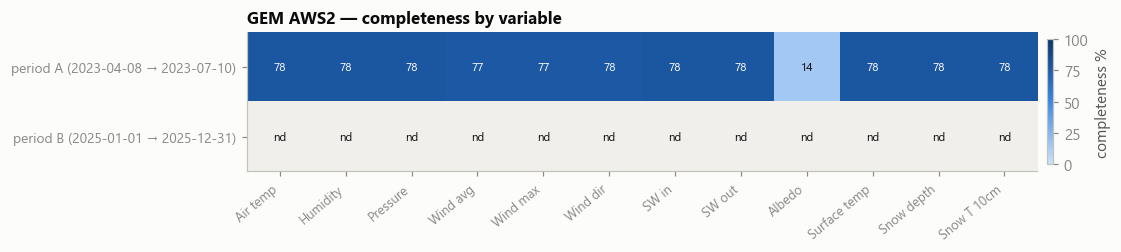

'nd' = period entirely outside the published record (GEM releases lag; the record ends 2024-12-31).
Albedo is low by design: computed only 11:00-15:00 and deleted around polar night.


In [5]:
# ---- completeness heatmap: period x variable ----
var_order = list(VARS)
var_labels = [VARS[v]['short'] for v in var_order]
period_rows = list(PERIODS)
mat = np.full((len(period_rows), len(var_order)), np.nan)
for i, p in enumerate(period_rows):
    if p in raw:
        row = summary[summary['period'] == p].set_index('variable')['completeness']
        mat[i] = [row.get(v, 0) * 100 for v in var_order]
cmap = CMAP_SEQ.copy()
cmap.set_bad(NEUTRAL)
fig, ax = plt.subplots(figsize=(11, 2.4))
im = ax.imshow(np.ma.masked_invalid(mat), cmap=cmap, vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(len(var_order)), var_labels, rotation=40, ha='right', fontsize=8.5)
ax.set_yticks(range(len(period_rows)),
              [f'period {p} ({PERIODS[p][0][:10]} → {PERIODS[p][1][:10]})' for p in period_rows], fontsize=9)
ax.grid(False)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat[i, j]
        ax.text(j, i, 'nd' if np.isnan(val) else f'{val:.0f}', ha='center', va='center', fontsize=7.5,
                color='#ffffff' if (not np.isnan(val) and val > 55) else INK)
cbar = fig.colorbar(im, ax=ax, shrink=0.9, pad=0.01)
cbar.set_label('completeness %', color=INK2)
ax.set_title('GEM AWS2 — completeness by variable', loc='left')
plt.tight_layout()
plt.show()
print("'nd' = period entirely outside the published record (GEM releases lag; the record ends 2024-12-31)."
      "\nAlbedo is low by design: computed only 11:00-15:00 and deleted around polar night.")


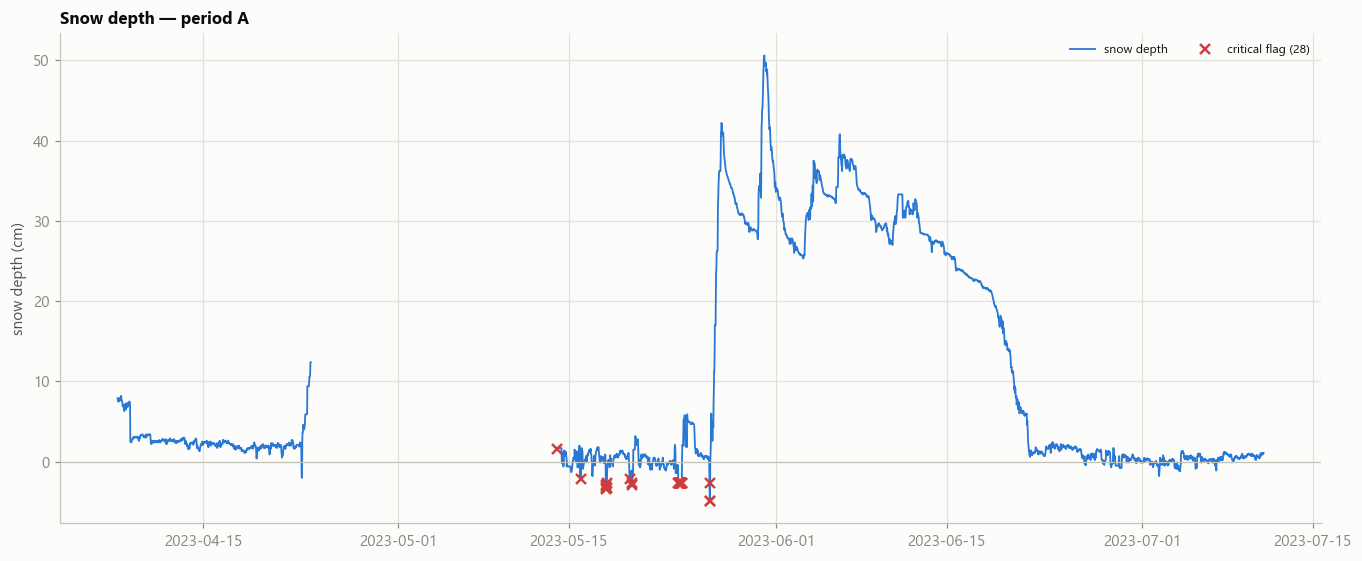

In [11]:
# ---- period A: snow depth + air/snow temperatures with critical flags ----
for p, df in sorted(raw.items()):
    fig, axes = plt.subplots(1, 1, figsize=(12.5, 5.2), sharex=True)

    ax = axes
    col = df['snow_depth']
    ax.plot(col.index, col.values * 100, color=SERIES, lw=1.2, label='snow depth')
    fl = flags[(flags['period'] == p) & (flags['variable'] == 'snow_depth') &
               flags['check'].isin(CRITICAL_CHECKS)]
    if len(fl):
        ax.plot(fl['ts'], fl['value'] * 100, 'x', color=CRITICAL_C, ms=6, mew=1.6,
                label=f'critical flag ({len(fl)})')
    wfl = flags[(flags['period'] == p) & (flags['variable'] == 'snow_depth') &
                (flags['check'] == 'melt_inconsistency')]
    if len(wfl):
        for t in wfl['ts']:
            ax.axvspan(t, t + pd.Timedelta(days=1), color=WARNING_C, alpha=0.25, lw=0)
        ax.plot([], [], 's', color=WARNING_C, alpha=0.5, label=f'melt-inconsistency day ({len(wfl)})')
    ax.axhline(0, color=BASELINE, lw=0.8)
    ax.set_ylabel('snow depth (cm)')
    ax.legend(loc='upper right', ncols=3, fontsize=8)
    ax.set_title(f'Snow depth — period {p}', loc='left')

    # ax = axes[1]
    # ax.plot(df.index, df['T_air'], color=SERIES, lw=1.0, label='air T (3 m)')
    # ax.plot(df.index, df['T_snow10cm'], color=INK2, lw=0.9, alpha=0.8, label='snow/air T (10 cm, valid only under snow)')
    # ax.axhline(0, color=BASELINE, lw=0.8)
    # ax.set_ylabel('°C')
    # ax.legend(loc='upper right', ncols=2, fontsize=8)
    # ax.set_title('Temperatures', loc='left')

    # axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axes[-1].xaxis.get_major_locator()))
    plt.tight_layout()
    plt.show()


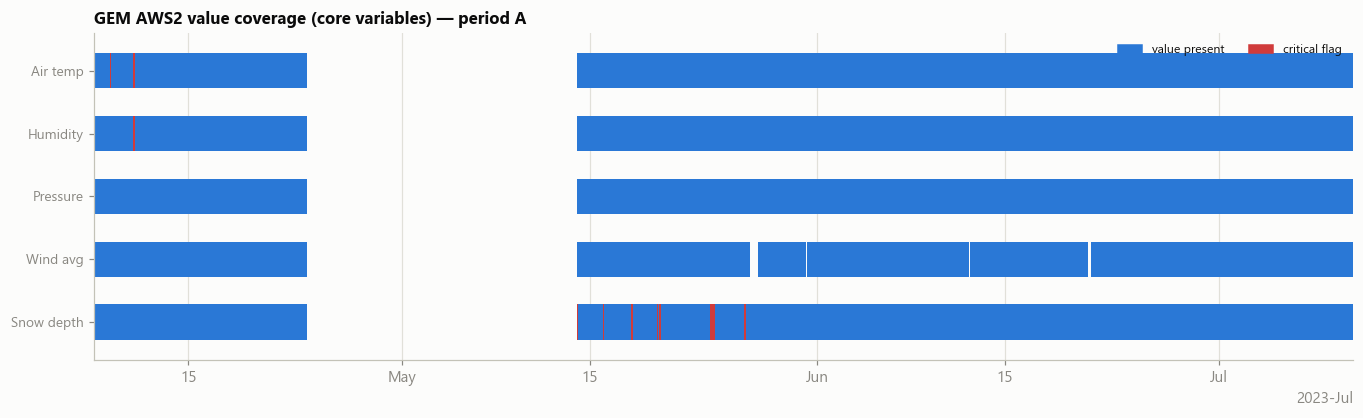

In [7]:
# ---- value coverage timeline for the core variables ----
for p, df in sorted(raw.items()):
    start, end = pd.Timestamp(PERIODS[p][0]), pd.Timestamp(PERIODS[p][1])
    fig, ax = plt.subplots(figsize=(12.5, 0.5 * len(CORE_VARS) + 1.4))
    for i, v in enumerate(CORE_VARS):
        y = len(CORE_VARS) - 1 - i
        present = df[v].notna()
        run = (present != present.shift()).cumsum()
        for _, seg in present.groupby(run):
            if seg.iloc[0]:
                x0 = mdates.date2num(seg.index[0])
                x1 = mdates.date2num(seg.index[-1] + pd.Timedelta(minutes=30))
                ax.broken_barh([(x0, x1 - x0)], (y - 0.28, 0.56), color=SERIES, lw=0)
        fl = flags[(flags['period'] == p) & (flags['variable'] == v) & flags['check'].isin(CRITICAL_CHECKS)]
        for t in pd.to_datetime(fl['ts'].unique()):
            ax.broken_barh([(mdates.date2num(t), 2 / 24)], (y - 0.28, 0.56), color=CRITICAL_C, lw=0)
    ax.set_yticks(range(len(CORE_VARS)), [VARS[v]['short'] for v in reversed(CORE_VARS)], fontsize=9)
    ax.set_ylim(-0.6, len(CORE_VARS) - 0.4)
    ax.set_xlim(mdates.date2num(start), mdates.date2num(end))
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.grid(axis='y', visible=False)
    ax.legend(handles=[Patch(color=SERIES, label='value present'),
                       Patch(color=CRITICAL_C, label='critical flag')],
              loc='upper right', ncols=2, fontsize=8)
    ax.set_title(f'GEM AWS2 value coverage (core variables) — period {p}', loc='left')
    plt.tight_layout()
    plt.show()


## 5. Cross-product coherence vs DMI Aasiaat

GEM AWS2 vs the **cleaned** DMI 422000 Aasiaat record (`results/clean_422000_<period>.csv`, from
`dmi_sanity_checks.ipynb`) — ~70 km apart across Disko Bay, so agreement is loose but gross sensor
error would show. Pressure is compared after removing the median offset (GEM measures station-level
pressure at ~25 m; DMI reports mean-sea-level). Disagreements are **warning** flags
(`cross_product`). Skipped gracefully if the DMI cleaned files are absent.

In [8]:
for p in sorted(raw):
    dmi_file = RESULTS_DIR / f'clean_422000_{p}.csv'
    if not dmi_file.exists():
        print(f'period {p}: {dmi_file.name} not found — run dmi_sanity_checks.ipynb first; skipping')
        continue
    dmi = pd.read_csv(dmi_file, parse_dates=['ts'], index_col='ts')
    gem_h = raw[p][raw[p].index.minute == 0]   # GEM 30-min -> hourly to match DMI
    pairs = [('T_air', '101', THRESHOLDS['cross_dt'], 'degC', False),
             ('P_air', '401', THRESHOLDS['cross_dp'], 'hPa', True)]
    for gv, dv, thr, unit, deoffset in pairs:
        both = pd.concat([gem_h[gv].rename('gem'), dmi[dv].rename('dmi')], axis=1).dropna()
        if not len(both):
            print(f'period {p} {gv}: no overlap')
            continue
        diff = both['gem'] - both['dmi']
        offset = diff.median() if deoffset else 0.0
        bad = (diff - offset).abs() > thr
        print(f'period {p}  {VARS[gv]["short"]:<9} vs DMI {dv}: {len(both)} common hours, '
              f'median offset {diff.median():+.1f} {unit}, |resid|>{thr}: {int(bad.sum())}')
        if bad.any():
            flags = pd.concat([flags, pd.DataFrame({
                'period': p, 'ts': both.index[bad], 'variable': gv,
                'check': 'cross_product', 'value': both['gem'][bad].values})], ignore_index=True)


period A  Air temp  vs DMI 101: 1766 common hours, median offset +0.3 degC, |resid|>8.0: 6
period A  Pressure  vs DMI 401: 1766 common hours, median offset -1.0 hPa, |resid|>5.0: 0


## 6. Verdicts & cleaned export

Same rules as the DMI notebook, applied to the core variables (air T, humidity, pressure, wind avg,
**snow depth**): **NO DATA** / **FAIL** (any core completeness < 50 % or critical flags > 2 %) /
**PASS** (all ≥ 80 %, flags ≤ 0.5 %, stuck-sensor ≤ 5 %) / **PASS WITH WARNINGS** in between.
The cleaned export masks critically flagged values and clamps bare-ground snow noise
([−0.02 m, 0) → 0).

In [9]:
for stale in RESULTS_DIR.glob('clean_GEM_AWS2_*.csv'):
    stale.unlink()

verdict_rows = []
for p in PERIODS:
    if p not in raw:
        reason = 'period outside the published record (GEM release lags; record ends '
        reason += f'{full.index.max():%Y-%m-%d} UTC) — re-download from data.g-e-m.dk when updated'
        verdict_rows.append(dict(period=p, site=SITE['name'], verdict='NO DATA', reasons=reason,
                                 **{f'comp_{v}': np.nan for v in CORE_VARS}))
        continue

    df = raw[p]
    cleaned = df.copy()
    fl = flags[flags['period'] == p]
    crit = fl[fl['check'].isin(CRITICAL_CHECKS)]
    for v, grp in crit.groupby('variable'):
        cleaned.loc[cleaned.index.isin(grp['ts']), v] = np.nan
    sd = cleaned['snow_depth']
    cleaned['snow_depth'] = sd.where(~((sd >= THRESHOLDS['snow_neg_clamp']) & (sd < 0)), 0.0)
    cleaned.to_csv(RESULTS_DIR / f'clean_GEM_AWS2_{p}.csv')

    comp, flag_frac, pers_frac = {}, {}, {}
    for v in CORE_VARS:
        comp[v] = cleaned[v].notna().sum() / (STEPS_PER_DAY * n_days[p])
        n_obs = max(int(df[v].notna().sum()), 1)
        flag_frac[v] = ((crit['variable'] == v).sum()) / n_obs
        pers_frac[v] = ((fl['check'] == 'persistence') & (fl['variable'] == v)).sum() / n_obs

    if min(comp.values()) < THRESHOLDS['completeness_min'] or max(flag_frac.values()) > THRESHOLDS['flagged_max']:
        verdict = 'FAIL'
    elif (min(comp.values()) >= THRESHOLDS['completeness_pass']
          and max(flag_frac.values()) <= THRESHOLDS['flagged_pass']
          and max(pers_frac.values()) <= THRESHOLDS['persistence_frac']):
        verdict = 'PASS'
    else:
        verdict = 'PASS WITH WARNINGS'

    reasons = []
    for v in CORE_VARS:
        vname = VARS[v]['short']
        if comp[v] < THRESHOLDS['completeness_pass']:
            reasons.append(f'{vname} completeness {comp[v]:.0%}')
        if flag_frac[v] > THRESHOLDS['flagged_pass']:
            reasons.append(f'{vname} critically flagged {flag_frac[v]:.1%}')
        if pers_frac[v] > THRESHOLDS['persistence_frac']:
            reasons.append(f'{vname} stuck-sensor flags {pers_frac[v]:.1%}')
    n_melt = int((fl['check'] == 'melt_inconsistency').sum())
    if n_melt:
        reasons.append(f'{n_melt} melt-inconsistency days')
    n_cross = int((fl['check'] == 'cross_product').sum())
    if n_cross:
        reasons.append(f'{n_cross} cross-product disagreements vs DMI Aasiaat')
    verdict_rows.append(dict(period=p, site=SITE['name'], verdict=verdict,
                             reasons='; '.join(reasons) or 'all checks passed',
                             **{f'comp_{v}': round(comp[v], 3) for v in CORE_VARS}))

verdicts = pd.DataFrame(verdict_rows)
verdicts.to_csv(RESULTS_DIR / 'gem_aws2_verdicts.csv', index=False)
print(f'Wrote {RESULTS_DIR / "gem_aws2_verdicts.csv"} and '
      f'{len(list(RESULTS_DIR.glob("clean_GEM_AWS2_*.csv")))} cleaned files.')
display(verdicts)


Wrote c:\Users\marti\Desktop\DMI stations\results\gem_aws2_verdicts.csv and 1 cleaned files.


,period,site,verdict,reasons,comp_T_air,comp_RH,comp_P_air,comp_wind_avg,comp_snow_depth
0,A,GEM GeoBasis Disko AWS2,PASS WITH WARNINGS,Air temp completeness 78%; Humidity completene...,0.785,0.785,0.785,0.774,0.779
1,B,GEM GeoBasis Disko AWS2,NO DATA,period outside the published record (GEM relea...,NaN,NaN,NaN,NaN,NaN


In [10]:
# ---- positive controls: documented ground truths must be reproduced ----
v = verdicts.set_index('period')
assert v.loc['B', 'verdict'] == 'NO DATA', 'GEM record ends 2024-12-31: period B must be NO DATA'

# the documented 2023-04-23 -> 2023-05-13 communication failure must appear as a ~480 h missing run
ga = gap_tables['A']
t_runs = ga[ga['variable'] == 'T_air']
assert len(t_runs) and t_runs['hours'].max() > 400, 'the documented April-May 2023 comms gap was not detected'
big = t_runs.loc[t_runs['hours'].idxmax()]
assert pd.Timestamp('2023-04-20') < big['start'] < pd.Timestamp('2023-04-30')

assert (RESULTS_DIR / 'clean_GEM_AWS2_A.csv').exists()
clean_a = pd.read_csv(RESULTS_DIR / 'clean_GEM_AWS2_A.csv', parse_dates=['ts'], index_col='ts')
assert float(clean_a['snow_depth'].min()) >= 0, 'cleaned snow depth must be non-negative'
print('All positive-control assertions passed.')


All positive-control assertions passed.


## 7. How to use this downstream

1. **GEM AWS2 is the in-situ snow-depth reference for Disko Bay** — the DMI network has none.
   Use `results/clean_GEM_AWS2_A.csv` (UTC, 30-min) for period A. Period B is not published yet:
   re-download the three AWS2 datasets from [data.g-e-m.dk](https://data.g-e-m.dk) when the 2025
   release appears, drop them into `GEM/`, and re-run this notebook unchanged.
2. **Snowfall-rate proxy:** positive Δ`snow_depth` between consecutive steps ⇒ accumulation;
   convert to water equivalent with an assumed fresh-snow density (~100–200 kg/m³). Treat rises on
   days flagged `melt_inconsistency` or with high wind (drifting) with suspicion. Albedo jumps and
   the 10-cm thermistor corroborate real snowfall events.
3. **Together with DMI:** Aasiaat (422000) contributes the only actual precipitation gauge;
   GEM AWS2 contributes snow depth ~250 m from the failed DMI 421900 — combined, the two products
   cover both sides of the bay for period A.
4. Attribution: data are CC-BY-SA-4.0 — cite the three GEM DOIs (see intro) in anything published.